# Paraphrasing
| # | Training activations | Test activations | Description |
|---|---------------------|-----------------|-------------|
| 1 | 600 original | 2000 original | Linear probe: no paraphrasing |
| 2 | 3000 augmented | 2000 (prob-aggregated) | Linear probe: augmentation, aggregate test probs |
| 3 | 3000 augmented | 2000 (prob-aggregated) | Linear probe: consistency-regularized training |
| 4 | 600 original | 2000 original | SAPLMA MLP: no paraphrasing |
| 5 | 3000 augmented | 2000 (prob-aggregated) | SAPLMA MLP: augmentation, aggregate test probs |

Run each experiment across three train/test settings:
- cities, FEVER-test
- facts_true_false, FEVER-test
- FEVER-train, FEVER-test

**Experiments 2, 3 & 5:** At test time the probe scores all 10,000 paraphrased examples independently, then averages the predicted probabilities across the 5 versions of each original statement:

$$\hat{p}(x) = \frac{1}{N}\sum_{i=1}^{N} \hat{p}_i$$

This averaged probability is used for AUROC/AUPRC and thresholded at 0.5 for accuracy.

**Experiment 3** adds a consistency regularization term to the BCE loss:

$$\mathcal{L} = \mathcal{L}_\text{BCE} + \lambda \cdot \frac{1}{G}\sum_{g=1}^{G} \text{Var}\bigl(\hat{p}(x_{g,1}), \ldots, \hat{p}(x_{g,5})\bigr)$$

This penalizes the probe for assigning different probabilities to paraphrases of the same statement. We select $\lambda$ per domain via **5-fold group cross-validation** on the training paraphrases, sweeping $\lambda \in \{0.1, 0.5, 1.0, 5.0, 10.0\}$. Folds are split at the *statement* level (groups of 5 paraphrases stay together) to avoid leaking paraphrase information across train/val. The $\lambda$ with the highest mean CV AUROC is selected, then the probe is retrained on all training data with that $\lambda$.

**Experiments 4 & 5** replace the linear probe with the SAPLMA MLP architecture from [Azaria & Mitchell (2023)](https://arxiv.org/abs/2304.13734): three hidden layers (256 to 128 to 64) with ReLU activations and a sigmoid output. Following the original paper, the MLP is trained for only 5 epochs with Adam and minibatch SGD (batch size 32). Experiment 4 mirrors Exp 1 (original data, no paraphrasing) while Experiment 5 mirrors Exp 2 (augmented training, probability aggregation at test time).

**Ablation:** Experiments 2 and 5 combine training-side augmentation with test-time probability aggregation. To disentangle these, we also evaluate the augmentation-trained probes on the original 2000 test statements without aggregation. 

In [14]:
# Imports
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob
from sklearn.metrics import accuracy_score, roc_auc_score, average_precision_score

from probes import LRProbe

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
layer = 12

print(f"Device: {device}")

Device: cpu


In [15]:
# Load activations

PARA_ACTS = os.path.join('para_acts', 'llama-2-7b')
PARA_DATA = 'para_datasets'


def load_acts(dataset_name, layer=12, center=True):
    """Load activations from para_acts/, matching collect_acts convention."""
    d = os.path.join(PARA_ACTS, dataset_name)
    files = glob(os.path.join(d, f'layer_{layer}_*.pt'))
    if not files:
        raise FileNotFoundError(f"No activation files in {d}")

    def batch_idx(p):
        return int(os.path.basename(p).rsplit('.', 1)[0].split('_')[-1])

    files.sort(key=batch_idx)
    acts = torch.cat([torch.load(f, map_location='cpu') for f in files], dim=0).float()
    if center:
        acts = acts - acts.mean(dim=0)
    return acts.to(device)


def load_labels(csv_name):
    """Load labels from a para_datasets CSV."""
    df = pd.read_csv(os.path.join(PARA_DATA, csv_name))
    return torch.tensor(df['label'].values, dtype=torch.float32).to(device), df


# ── Original (base) datasets ──────────────────────────────────────────────────

cities_acts   = load_acts('train_cities')
cities_labels, _ = load_labels('train_cities.csv')

facts_acts    = load_acts('train_facts')
facts_labels, _ = load_labels('train_facts.csv')

fever_tr_acts   = load_acts('train_fever')
fever_tr_labels, _ = load_labels('train_fever.csv')

fever_te_acts   = load_acts('test_fever')
fever_te_labels, fever_te_df = load_labels('test_fever.csv')

# Load datasets

para_cities_acts   = load_acts('para_train_cities')
para_cities_labels, para_cities_df = load_labels('para_train_cities.csv')

para_facts_acts    = load_acts('para_train_facts')
para_facts_labels, para_facts_df = load_labels('para_train_facts.csv')

para_fever_tr_acts   = load_acts('para_train_fever')
para_fever_tr_labels, para_fever_tr_df = load_labels('para_train_fever.csv')

para_fever_te_acts   = load_acts('para_test_fever')
para_fever_te_labels, para_fever_te_df = load_labels('para_test_fever.csv')

print("Original datasets:")
for name, a, l in [
    ('train_cities',  cities_acts,    cities_labels),
    ('train_facts',   facts_acts,     facts_labels),
    ('train_fever',   fever_tr_acts,  fever_tr_labels),
    ('test_fever',    fever_te_acts,  fever_te_labels),
]:
    print(f"  {name:20s}  acts: {a.shape}  labels: {l.shape}")

print("\nParaphrased datasets:")
for name, a, l in [
    ('para_train_cities', para_cities_acts,    para_cities_labels),
    ('para_train_facts',  para_facts_acts,     para_facts_labels),
    ('para_train_fever',  para_fever_tr_acts,  para_fever_tr_labels),
    ('para_test_fever',   para_fever_te_acts,  para_fever_te_labels),
]:
    print(f"  {name:20s}  acts: {a.shape}  labels: {l.shape}")

Original datasets:
  train_cities          acts: torch.Size([600, 4096])  labels: torch.Size([600])
  train_facts           acts: torch.Size([600, 4096])  labels: torch.Size([600])
  train_fever           acts: torch.Size([600, 4096])  labels: torch.Size([600])
  test_fever            acts: torch.Size([2000, 4096])  labels: torch.Size([2000])

Paraphrased datasets:
  para_train_cities     acts: torch.Size([3000, 4096])  labels: torch.Size([3000])
  para_train_facts      acts: torch.Size([3000, 4096])  labels: torch.Size([3000])
  para_train_fever      acts: torch.Size([3000, 4096])  labels: torch.Size([3000])
  para_test_fever       acts: torch.Size([10000, 4096])  labels: torch.Size([10000])


In [16]:
# Get average activations

def average_paraphrase_acts(acts, df, group_size=5):
    """
    Average activations across paraphrase groups.
    Each group of `group_size` consecutive rows shares the same original_statement.
    Returns (averaged_acts, labels) with one vector per original statement.
    """
    n = acts.shape[0]
    assert n == len(df), f"acts ({n}) and df ({len(df)}) length mismatch"
    assert n % group_size == 0, f"{n} not divisible by {group_size}"

    n_groups = n // group_size
    avg = acts.view(n_groups, group_size, -1).mean(dim=1)  # (n_groups, dim)
    labels = df['label'].values[::group_size]               # one label per group
    labels = torch.tensor(labels, dtype=torch.float32).to(device)
    return avg, labels


# Get average activations (pt2)

avg_cities_acts,   avg_cities_labels   = average_paraphrase_acts(para_cities_acts,   para_cities_df)
avg_facts_acts,    avg_facts_labels    = average_paraphrase_acts(para_facts_acts,    para_facts_df)
avg_fever_tr_acts, avg_fever_tr_labels = average_paraphrase_acts(para_fever_tr_acts, para_fever_tr_df)
avg_fever_te_acts, avg_fever_te_labels = average_paraphrase_acts(para_fever_te_acts, para_fever_te_df)

print("Para-averaged shapes:")
print(f"  cities train:  {avg_cities_acts.shape}")
print(f"  facts train:   {avg_facts_acts.shape}")
print(f"  fever train:   {avg_fever_tr_acts.shape}")
print(f"  fever test:    {avg_fever_te_acts.shape}")

Para-averaged shapes:
  cities train:  torch.Size([600, 4096])
  facts train:   torch.Size([600, 4096])
  fever train:   torch.Size([600, 4096])
  fever test:    torch.Size([2000, 4096])


In [17]:
# Other helpers

def evaluate(y_true, y_prob):
    """Compute accuracy, AUROC, AUPRC from ground-truth labels and predicted probs."""
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    y_pred = (y_prob >= 0.5).astype(int)
    acc = accuracy_score(y_true, y_pred)
    try:
        auroc = roc_auc_score(y_true, y_prob)
        auprc = average_precision_score(y_true, y_prob)
    except ValueError:
        auroc = auprc = float('nan')
    return {'accuracy': acc, 'auroc': auroc, 'auprc': auprc}


def probe_predict(probe, acts):
    """Get predicted probabilities from an LRProbe."""
    with torch.no_grad():
        return probe(acts).cpu().numpy()


def aggregate_probs(probs, group_size=5):
    """
    Average predicted probabilities across paraphrase groups.
    probs: (N,) array where N = n_originals * group_size
    Returns: (n_originals,) averaged probabilities
    """
    n = len(probs)
    assert n % group_size == 0
    return probs.reshape(-1, group_size).mean(axis=1)


def train_consistency_probe(para_acts, para_labels, group_size=5, lr=0.001,
                            weight_decay=0.1, lam=1.0, epochs=200, device='cpu'):
    """
    LRProbe with BCE + λ · mean(Var(preds within group)).
    Penalizes the probe for giving different predictions to paraphrases
    of the same statement.
    """
    para_acts = para_acts.to(device)
    para_labels = para_labels.to(device)
    n_groups = para_acts.shape[0] // group_size

    probe = LRProbe(para_acts.shape[-1]).to(device)
    opt = torch.optim.AdamW(probe.parameters(), lr=lr, weight_decay=weight_decay)

    for _ in range(epochs):
        opt.zero_grad()
        probs = probe(para_acts)
        bce = torch.nn.BCELoss()(probs, para_labels)
        consistency = probs.view(n_groups, group_size).var(dim=1).mean()
        loss = bce + lam * consistency
        loss.backward()
        opt.step()

    return probe


class SAPLMAProbe(torch.nn.Module):
    """
    3-layer MLP from Azaria & Mitchell (2023).
    256→128→64→1, ReLU activations, sigmoid output.
    Trained with Adam, BCE, 5 epochs, batch_size=32.
    """
    def __init__(self, d_in):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(d_in, 256),
            torch.nn.ReLU(),
            torch.nn.Linear(256, 128),
            torch.nn.ReLU(),
            torch.nn.Linear(128, 64),
            torch.nn.ReLU(),
            torch.nn.Linear(64, 1),
            torch.nn.Sigmoid(),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

    @classmethod
    def from_data(cls, acts, labels, lr=0.001, epochs=5, batch_size=32, seed=42, device='cpu'):
        torch.manual_seed(seed)
        acts, labels = acts.to(device), labels.to(device)
        probe = cls(acts.shape[-1]).to(device)
        opt = torch.optim.Adam(probe.parameters(), lr=lr)
        n = acts.shape[0]
        for _ in range(epochs):
            perm = torch.randperm(n, device=device)
            for i in range(0, n, batch_size):
                idx = perm[i:i + batch_size]
                opt.zero_grad()
                loss = torch.nn.BCELoss()(probe(acts[idx]), labels[idx])
                loss.backward()
                opt.step()
        return probe


def cv_select_lambda(para_acts, para_labels, lambdas, k=5, group_size=5,
                     lr=0.001, weight_decay=0.1, epochs=200, seed=42, device='cpu'):
    """
    Group k-fold CV to select λ for consistency-regularized training.
    Splits at the statement level so paraphrase groups stay intact.
    Returns (best_lambda, {lambda: mean_cv_auroc}).
    """
    n_groups = para_acts.shape[0] // group_size
    rng = np.random.RandomState(seed)
    group_order = rng.permutation(n_groups)
    folds = np.array_split(group_order, k)

    mean_aurocs = {}
    for lam in lambdas:
        fold_aurocs = []
        for fi in range(k):
            val_groups = folds[fi]
            train_groups = np.concatenate([folds[j] for j in range(k) if j != fi])

            tr_rows = np.concatenate([np.arange(g * group_size, (g + 1) * group_size)
                                      for g in train_groups])
            va_rows = np.concatenate([np.arange(g * group_size, (g + 1) * group_size)
                                      for g in val_groups])

            probe = train_consistency_probe(
                para_acts[tr_rows], para_labels[tr_rows],
                group_size=group_size, lam=lam, lr=lr,
                weight_decay=weight_decay, epochs=epochs, device=device)

            va_probs = probe_predict(probe, para_acts[va_rows])
            agg_probs = aggregate_probs(va_probs, group_size=group_size)
            agg_labels = para_labels[va_rows].cpu().numpy()[::group_size].astype(int)

            try:
                fold_aurocs.append(roc_auc_score(agg_labels, agg_probs))
            except ValueError:
                fold_aurocs.append(0.5)

        mean_aurocs[lam] = np.mean(fold_aurocs)

    return max(mean_aurocs, key=mean_aurocs.get), mean_aurocs

---
## Run

In [18]:
# Store all results: results[exp_num][domain] = {'train': {...}, 'test': {...}}
results = {1: {}, 2: {}, 3: {}, 4: {}, 5: {}}

domains = {
    'cities': {
        'orig_acts':     cities_acts,       'orig_labels':     cities_labels,
        'para_acts':     para_cities_acts,  'para_labels':     para_cities_labels,
    },
    'facts': {
        'orig_acts':     facts_acts,        'orig_labels':     facts_labels,
        'para_acts':     para_facts_acts,   'para_labels':     para_facts_labels,
    },
    'fever': {
        'orig_acts':     fever_tr_acts,     'orig_labels':     fever_tr_labels,
        'para_acts':     para_fever_tr_acts,'para_labels':     para_fever_tr_labels,
    },
}

# Test sets (all refer to FEVER-test)
test_orig_acts   = fever_te_acts
test_orig_labels = fever_te_labels.cpu().numpy().astype(int)
test_para_acts   = para_fever_te_acts
test_para_labels = para_fever_te_labels.cpu().numpy().astype(int)
test_agg_labels  = test_para_labels[::5]


for domain_name, d in domains.items():
    print(f"\n{'='*60}")
    print(f"  Domain: {domain_name}")
    print(f"{'='*60}")

    # Exp 1
    probe1 = LRProbe.from_data(d['orig_acts'], d['orig_labels'], device=device)
    tr1 = evaluate(d['orig_labels'].cpu().numpy(), probe_predict(probe1, d['orig_acts']))
    te1_probs = probe_predict(probe1, test_orig_acts)
    te1 = evaluate(test_orig_labels, te1_probs)
    results[1][domain_name] = {'train': tr1, 'test': te1, 'test_probs': te1_probs, 'test_labels': test_orig_labels}
    print(f"  Exp 1 (baseline):     train acc {tr1['accuracy']:.4f}  |  test acc {te1['accuracy']:.4f}  AUROC {te1['auroc']:.4f}  AUPRC {te1['auprc']:.4f}")

    # Exp 2
    probe2 = LRProbe.from_data(d['para_acts'], d['para_labels'], device=device)
    tr2 = evaluate(d['para_labels'].cpu().numpy(), probe_predict(probe2, d['para_acts']))
    raw_te_probs = probe_predict(probe2, test_para_acts)
    agg_te_probs = aggregate_probs(raw_te_probs, group_size=5)
    te2 = evaluate(test_agg_labels, agg_te_probs)
    te2_orig_probs = probe_predict(probe2, test_orig_acts)
    te2_orig = evaluate(test_orig_labels, te2_orig_probs)
    results[2][domain_name] = {
        'train': tr2, 'test': te2, 'test_probs': agg_te_probs, 'test_labels': test_agg_labels,
        'test_no_agg': te2_orig, 'test_no_agg_probs': te2_orig_probs,
    }
    print(f"  Exp 2 (augment+agg):  train acc {tr2['accuracy']:.4f}  |  test acc {te2['accuracy']:.4f}  AUROC {te2['auroc']:.4f}  AUPRC {te2['auprc']:.4f}")

    # Exp 3
    best_lam, cv_aurocs = cv_select_lambda(
        d['para_acts'], d['para_labels'],
        lambdas=[0.1, 0.5, 1.0, 5.0, 10.0], k=5, device=device)

    probe3 = train_consistency_probe(
        d['para_acts'], d['para_labels'], lam=best_lam, device=device)
    tr3 = evaluate(d['para_labels'].cpu().numpy(),
                   probe_predict(probe3, d['para_acts']))
    raw_te3 = probe_predict(probe3, test_para_acts)
    agg_te3 = aggregate_probs(raw_te3, group_size=5)
    te3 = evaluate(test_agg_labels, agg_te3)

    results[3][domain_name] = {
        'train': tr3, 'test': te3,
        'test_probs': agg_te3, 'test_labels': test_agg_labels,
        'best_lam': best_lam, 'cv_aurocs': cv_aurocs,
    }
    cv_str = '  '.join(f'λ={l}:{cv_aurocs[l]:.4f}' for l in cv_aurocs)
    print(f"  Exp 3 (consist-reg):  train acc {tr3['accuracy']:.4f}  |  "
          f"test acc {te3['accuracy']:.4f}  AUROC {te3['auroc']:.4f}  "
          f"AUPRC {te3['auprc']:.4f}  (CV λ={best_lam})")

    # Exp 4
    probe4 = SAPLMAProbe.from_data(d['orig_acts'], d['orig_labels'], device=device)
    tr4 = evaluate(d['orig_labels'].cpu().numpy(), probe_predict(probe4, d['orig_acts']))
    te4_probs = probe_predict(probe4, test_orig_acts)
    te4 = evaluate(test_orig_labels, te4_probs)
    results[4][domain_name] = {
        'train': tr4, 'test': te4,
        'test_probs': te4_probs, 'test_labels': test_orig_labels,
    }
    print(f"  Exp 4 (SAPLMA):       train acc {tr4['accuracy']:.4f}  |  "
          f"test acc {te4['accuracy']:.4f}  AUROC {te4['auroc']:.4f}  "
          f"AUPRC {te4['auprc']:.4f}")

    # Exp 5
    probe5 = SAPLMAProbe.from_data(d['para_acts'], d['para_labels'], device=device)
    tr5 = evaluate(d['para_labels'].cpu().numpy(), probe_predict(probe5, d['para_acts']))
    raw_te5 = probe_predict(probe5, test_para_acts)
    agg_te5 = aggregate_probs(raw_te5, group_size=5)
    te5 = evaluate(test_agg_labels, agg_te5)
    te5_orig_probs = probe_predict(probe5, test_orig_acts)
    te5_orig = evaluate(test_orig_labels, te5_orig_probs)
    results[5][domain_name] = {
        'train': tr5, 'test': te5,
        'test_probs': agg_te5, 'test_labels': test_agg_labels,
        'test_no_agg': te5_orig, 'test_no_agg_probs': te5_orig_probs,
    }
    print(f"  Exp 5 (SAPLMA+para):  train acc {tr5['accuracy']:.4f}  |  "
          f"test acc {te5['accuracy']:.4f}  AUROC {te5['auroc']:.4f}  "
          f"AUPRC {te5['auprc']:.4f}")


  Domain: cities
  Exp 1 (baseline):     train acc 0.9983  |  test acc 0.5785  AUROC 0.6179  AUPRC 0.6119
  Exp 2 (augment+agg):  train acc 0.9390  |  test acc 0.6100  AUROC 0.6485  AUPRC 0.6059
  Exp 3 (consist-reg):  train acc 0.9487  |  test acc 0.6130  AUROC 0.6519  AUPRC 0.6238  (CV λ=10.0)
  Exp 4 (SAPLMA):       train acc 0.9767  |  test acc 0.5405  AUROC 0.5601  AUPRC 0.5388
  Exp 5 (SAPLMA+para):  train acc 0.9817  |  test acc 0.6210  AUROC 0.6519  AUPRC 0.6196

  Domain: facts
  Exp 1 (baseline):     train acc 0.9150  |  test acc 0.6470  AUROC 0.6913  AUPRC 0.6475
  Exp 2 (augment+agg):  train acc 0.8170  |  test acc 0.6710  AUROC 0.7157  AUPRC 0.6695
  Exp 3 (consist-reg):  train acc 0.7987  |  test acc 0.6665  AUROC 0.7053  AUPRC 0.6559  (CV λ=0.5)
  Exp 4 (SAPLMA):       train acc 0.9083  |  test acc 0.6355  AUROC 0.6793  AUPRC 0.6350
  Exp 5 (SAPLMA+para):  train acc 0.7913  |  test acc 0.6070  AUROC 0.7466  AUPRC 0.6989

  Domain: fever
  Exp 1 (baseline):     train acc

---
## Results

In [19]:
exp_names = {
    1: '1: LR baseline',
    2: '2: LR aug+agg',
    3: '3: LR consist-reg',
    4: '4: SAPLMA baseline',
    5: '5: SAPLMA aug+agg',
}

rows = []
for exp_num in [1, 2, 3, 4, 5]:
    for domain in ['cities', 'facts', 'fever']:
        r = results[exp_num][domain]
        name = exp_names[exp_num]
        if exp_num == 3:
            name += f" (λ={r['best_lam']})"
        rows.append({
            'Experiment': name,
            'Train domain': domain,
            'Train Acc':  r['train']['accuracy'],
            'Test Acc':   r['test']['accuracy'],
            'Test AUROC': r['test']['auroc'],
            'Test AUPRC': r['test']['auprc'],
        })

summary = pd.DataFrame(rows)
print(summary.to_string(index=False, float_format='%.4f'))

                Experiment Train domain  Train Acc  Test Acc  Test AUROC  Test AUPRC
            1: LR baseline       cities     0.9983    0.5785      0.6179      0.6119
            1: LR baseline        facts     0.9150    0.6470      0.6913      0.6475
            1: LR baseline        fever     0.9067    0.7455      0.8193      0.7888
             2: LR aug+agg       cities     0.9390    0.6100      0.6485      0.6059
             2: LR aug+agg        facts     0.8170    0.6710      0.7157      0.6695
             2: LR aug+agg        fever     0.8210    0.7460      0.8262      0.8055
3: LR consist-reg (λ=10.0)       cities     0.9487    0.6130      0.6519      0.6238
 3: LR consist-reg (λ=0.5)        facts     0.7987    0.6665      0.7053      0.6559
3: LR consist-reg (λ=10.0)        fever     0.8097    0.7400      0.8167      0.7887
        4: SAPLMA baseline       cities     0.9767    0.5405      0.5601      0.5388
        4: SAPLMA baseline        facts     0.9083    0.6355     

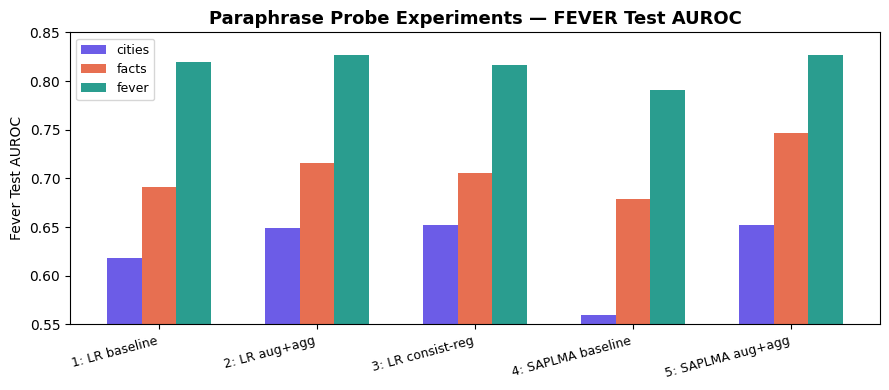

In [30]:
# Visualize AUROC (auto-zoomed y-axis)
fig, ax = plt.subplots(figsize=(9, 4))

all_exp = [1, 2, 3, 4, 5]
exp_labels = [exp_names[i] for i in all_exp]
x = np.arange(len(exp_labels))
width = 0.22
colors = ['#6C5CE7', '#E76F51', '#2A9D8F']

all_vals = []
for i, domain in enumerate(['cities', 'facts', 'fever']):
    vals = [results[exp][domain]['test']['auroc'] for exp in all_exp]
    ax.bar(x + i * width, vals, width, label=domain, color=colors[i])
    all_vals.extend(vals)

ax.set_ylim(0.55, 0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(exp_labels, fontsize=9, rotation=15, ha='right')
ax.set_ylabel('Fever Test AUROC')
ax.set_title('Paraphrase Probe Experiments — FEVER Test AUROC', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## Statistical significance test

The [DeLong test](https://doi.org/10.2307/2531595) compares two correlated AUROCs measured on the same test subjects. For each domain we compare the non-baseline experiments (2, 3, 5) against both baselines: Exp 1 (LR) and Exp 4 (SAPLMA).

In [21]:
from scipy.stats import norm

def delong_test(y_true, y_pred1, y_pred2):
    """
    DeLong test for comparing two correlated AUROCs.
    Both predictions must be on the same set of subjects.
    Returns (z_stat, two_sided_p_value).
    """
    y_true = np.asarray(y_true, dtype=int)
    y_pred1 = np.asarray(y_pred1, dtype=float)
    y_pred2 = np.asarray(y_pred2, dtype=float)

    pos = y_true == 1
    neg = y_true == 0
    m = pos.sum()
    n = neg.sum()

    s_pos1, s_neg1 = y_pred1[pos], y_pred1[neg]
    s_pos2, s_neg2 = y_pred2[pos], y_pred2[neg]

    # Placement values V10 (one per positive) and V01 (one per negative)
    def placements(s_pos, s_neg):
        V10 = np.array([np.mean((s_pos[i] > s_neg) + 0.5 * (s_pos[i] == s_neg))
                        for i in range(m)])
        V01 = np.array([np.mean((s_pos > s_neg[j]) + 0.5 * (s_pos == s_neg[j]))
                        for j in range(n)])
        return V10, V01

    V10_1, V01_1 = placements(s_pos1, s_neg1)
    V10_2, V01_2 = placements(s_pos2, s_neg2)

    auc1, auc2 = V10_1.mean(), V10_2.mean()

    S10 = np.cov(np.vstack([V10_1, V10_2]))
    S01 = np.cov(np.vstack([V01_1, V01_2]))
    S = S10 / m + S01 / n

    var_diff = S[0, 0] + S[1, 1] - 2 * S[0, 1]
    if var_diff <= 0:
        return 0.0, 1.0

    z = (auc1 - auc2) / np.sqrt(var_diff)
    p = 2 * norm.sf(abs(z))
    return z, p

# All 5 experiments produce 2000 predictions for the same 2000 FEVER test
# statements, so DeLong is valid for any pair.  We compare every non-baseline
# experiment against both baselines: Exp 1 (LR) and Exp 4 (SAPLMA).
delong_rows = []
for domain in ['cities', 'facts', 'fever']:
    for base_num in [1, 4]:
        for exp_num in [2, 3, 5]:
            r_base = results[base_num][domain]
            r_exp = results[exp_num][domain]
            labels = r_base['test_labels']
            probs_base = r_base['test_probs']
            probs_exp = r_exp['test_probs']
            auc_base = r_base['test']['auroc']
            auc_exp = r_exp['test']['auroc']
            z, p = delong_test(labels, probs_exp, probs_base)
            delong_rows.append({
                'Comparison': f'{exp_names[exp_num]}  vs  {exp_names[base_num]}',
                'Domain': domain,
                'AUROC base': auc_base,
                'AUROC exp': auc_exp,
                'AUROC delta': auc_exp - auc_base,
                'z': z,
                'p-value': p,
                'Sig (p<0.05)': 'Y' if p < 0.05 else 'N',
            })

delong_df = pd.DataFrame(delong_rows)
print(delong_df.to_string(index=False, float_format='%.4f'))

                               Comparison Domain  AUROC base  AUROC exp  AUROC delta       z  p-value Sig (p<0.05)
        2: LR aug+agg  vs  1: LR baseline cities      0.6179     0.6485       0.0306  2.7892   0.0053            Y
    3: LR consist-reg  vs  1: LR baseline cities      0.6179     0.6519       0.0340  3.2751   0.0011            Y
    5: SAPLMA aug+agg  vs  1: LR baseline cities      0.6179     0.6519       0.0340  3.3367   0.0008            Y
    2: LR aug+agg  vs  4: SAPLMA baseline cities      0.5601     0.6485       0.0884  7.5946   0.0000            Y
3: LR consist-reg  vs  4: SAPLMA baseline cities      0.5601     0.6519       0.0919  7.0101   0.0000            Y
5: SAPLMA aug+agg  vs  4: SAPLMA baseline cities      0.5601     0.6519       0.0918  7.1979   0.0000            Y
        2: LR aug+agg  vs  1: LR baseline  facts      0.6913     0.7157       0.0243  2.4486   0.0143            Y
    3: LR consist-reg  vs  1: LR baseline  facts      0.6913     0.7053       0.

---
## Ablation

Experiments 2 and 5 combine two mechanisms: (1) training on paraphrased examples and (2) averaging predictions over 5 paraphrases at test time. 

Here, we work to isolate the two effects.

In [23]:
ablation_rows = []
for domain in ['cities', 'facts', 'fever']:
    for exp_num, baseline_num, label in [
        (2, 1, 'LR'),
        (5, 4, 'SAPLMA'),
    ]:
        r = results[exp_num][domain]
        r_base = results[baseline_num][domain]
        ablation_rows.append({
            'Probe': label,
            'Domain': domain,
            'Baseline': r_base['test']['auroc'],
            'Aug train, no agg': r['test_no_agg']['auroc'],
            'Aug train + agg': r['test']['auroc'],
            'Δ (train aug only)': r['test_no_agg']['auroc'] - r_base['test']['auroc'],
            'Δ (+ test agg)': r['test']['auroc'] - r['test_no_agg']['auroc'],
        })

ablation_df = pd.DataFrame(ablation_rows)
print(ablation_df.to_string(index=False, float_format='%.4f'))

 Probe Domain  Baseline  Aug train, no agg  Aug train + agg  Δ (train aug only)  Δ (+ test agg)
    LR cities    0.6179             0.6118           0.6485             -0.0061          0.0367
SAPLMA cities    0.5601             0.6273           0.6519              0.0672          0.0245
    LR  facts    0.6913             0.6921           0.7157              0.0008          0.0235
SAPLMA  facts    0.6793             0.6977           0.7466              0.0184          0.0489
    LR  fever    0.8193             0.7789           0.8262             -0.0403          0.0473
SAPLMA  fever    0.7907             0.8067           0.8270              0.0161          0.0202
